# **Lab: 03 --- RNN --- Air Passengers**

En este primer paso construiremos una **Red Neuronal Recurrente simple** usando el dataset clásico de
**Air Passengers** (cantidad mensual de pasajeros de 1949 a 1960).

### Proceso:
1. **Carga del dataset**: Leeremos los datos y los convertiremos en una serie temporal.
2. **Normalización**: Escalaremos los valores entre 0 y 1 para facilitar el entrenamiento.
3. **Ventaneo de la serie**: Crearemos secuencias de entrada (X) y salida (y) para que la RNN aprenda patrones.
   - Ejemplo: con una ventana de 12 meses, los primeros 12 valores predicen el siguiente mes.
4. **Construcción de la RNN**:
   - Una capa `SimpleRNN` con 50 neuronas.
   - Una capa densa de salida que predice un valor futuro.
5. **Entrenamiento**: Usaremos `MSE` como función de pérdida y `Adam` como optimizador.
6. **Evaluación**: Visualizaremos las predicciones frente a los valores reales.

Este modelo nos permitirá realizar **predicciones univariadas** mes a mes.  
Más adelante lo extenderemos a **LSTM**, **GRU** y a predicción multi-paso.


# Paso 0: Conectar con Google Drive (Colab)

Montaremos Google Drive para:
- Leer el CSV de Air Passengers si ya lo subiste.
- Guardar resultados/modelos si lo deseas.

Si el archivo no está en Drive, el script **usará un respaldo en línea** (AirPassengers / airline-passengers).


In [2]:
# Montar Drive (funciona solo en Google Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("Drive montado.")
except Exception as e:
    IN_COLAB = False
    print("No estamos en Colab o no fue posible montar Drive. Continuamos sin Drive.")


Mounted at /content/drive
Drive montado.


# **Paso 1: Cargar y verificar el dataset (ruta en Drive)**

Usaremos el CSV en:  
`/content/drive/MyDrive/IA_02/Laboratorios/Lab03/AirPassengers.csv`

Verificaremos:
- columnas y primeras filas
- rango temporal y valores faltantes
- gráfico de la serie cruda (mensual)


Shape: (144,)
Rango de fechas: 1949-01-01 00:00:00 → 1960-12-01 00:00:00
Faltantes: 0


,passengers
month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


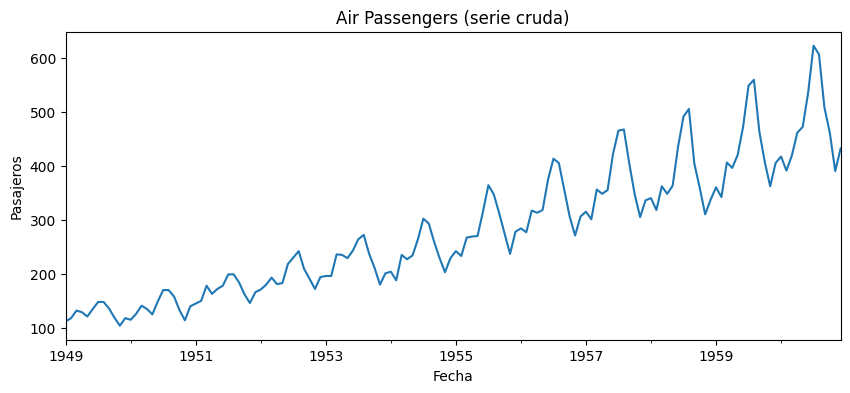

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

csv_path = "/content/drive/MyDrive/IA_02/Laboratorios/Lab03/AirPassengers.csv"

def load_airpassengers_local(path):
    df = pd.read_csv(path)
    # normalizar nombres
    low = {c.lower(): c for c in df.columns}
    # detectar columnas típicas
    if "month" in low:  tcol = low["month"]
    elif "period" in low: tcol = low["period"]
    else: tcol = df.columns[0]
    if "passengers" in low: vcol = low["passengers"]
    elif "value" in low:    vcol = low["value"]
    else: vcol = df.columns[1]
    df = df[[tcol, vcol]].copy()
    df.columns = ["month", "passengers"]
    df["month"] = pd.to_datetime(df["month"])
    s = df.sort_values("month").set_index("month").asfreq("MS")["passengers"].astype(float)
    return s

series = load_airpassengers_local(csv_path)

print("Shape:", series.shape)
print("Rango de fechas:", series.index.min(), "→", series.index.max())
print("Faltantes:", int(series.isna().sum()))
display(series.head())

plt.figure(figsize=(10,4))
series.plot()
plt.title("Air Passengers (serie cruda)")
plt.ylabel("Pasajeros"); plt.xlabel("Fecha")
plt.show()


# **Paso 2: Partición temporal (Train / Validación / Test)**

- **Train**: inicio → 1957-12  
- **Validación**: 1958-01 → 1959-12 (24 meses)  
- **Test**: 1960-01 → 1960-12 (12 meses)

Mostramos las divisiones sobre la serie.


Train: 1949-01-01 00:00:00 → 1957-12-01 00:00:00 (108)
Valid: 1958-01-01 00:00:00 → 1959-12-01 00:00:00 (24)
Test : 1960-01-01 00:00:00 → 1960-12-01 00:00:00 (12)


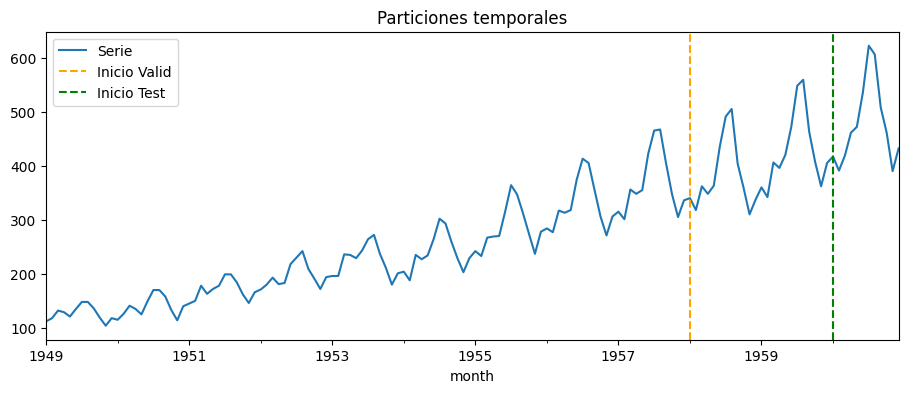

In [4]:
def temporal_split(s, valid_months=24, test_months=12):
    n = len(s)
    i_tr_end = n - valid_months - test_months
    i_va_end = n - test_months
    return s.iloc[:i_tr_end], s.iloc[i_tr_end:i_va_end], s.iloc[i_va_end:]

s_train, s_valid, s_test = temporal_split(series, 24, 12)

print("Train:", s_train.index.min(), "→", s_train.index.max(), f"({len(s_train)})")
print("Valid:", s_valid.index.min(), "→", s_valid.index.max(), f"({len(s_valid)})")
print("Test :", s_test.index.min(),  "→", s_test.index.max(),  f"({len(s_test)})")

plt.figure(figsize=(11,4))
series.plot(label="Serie")
plt.axvline(s_valid.index.min(), color="orange", linestyle="--", label="Inicio Valid")
plt.axvline(s_test.index.min(),  color="green",  linestyle="--", label="Inicio Test")
plt.title("Particiones temporales")
plt.legend(); plt.show()


# **Paso 3: Transformación y normalización**

- Transformación opcional `log1p` (para estabilizar varianza).
- Escalado **MinMax(0..1)** entrenado **solo con Train**.
- Guardamos funciones para invertir al final.


In [5]:
from sklearn.preprocessing import MinMaxScaler

USE_LOG1P = True

def forward_transform(s, scaler=None):
    arr = np.log1p(s.values.reshape(-1,1)) if USE_LOG1P else s.values.reshape(-1,1)
    if scaler is None:
        scaler = MinMaxScaler()
        arr = scaler.fit_transform(arr)
    else:
        arr = scaler.transform(arr)
    return arr.flatten(), scaler

def inverse_transform(arr, scaler):
    arr = scaler.inverse_transform(arr.reshape(-1,1)).flatten()
    return np.expm1(arr) if USE_LOG1P else arr

scaler = None
train_t, scaler = forward_transform(s_train, None)
valid_t, _      = forward_transform(s_valid, scaler)
test_t,  _      = forward_transform(s_test,  scaler)

print("Escala train -> min:", train_t.min(), "max:", train_t.max())


Escala train -> min: 0.0 max: 1.0


# **Paso 4: Ventaneo y construcción de la RNN (un paso)**

- Ventana **W = 12** (un año de historial).
- Predicción **1-paso** (siguiente mes).
- Modelo:
  - `SimpleRNN(50, tanh)`
  - `Dense(1)` de salida


In [6]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import numpy as np

def make_supervised(arr_1d, window=12):
    X, y = [], []
    for i in range(len(arr_1d) - window):
        X.append(arr_1d[i:i+window])
        y.append(arr_1d[i+window])
    return np.array(X)[:, :, None], np.array(y)

W = 12
X_tr, y_tr = make_supervised(train_t, W)
X_va, y_va = make_supervised(np.hstack([train_t, valid_t]), W)
X_te, y_te = make_supervised(np.hstack([train_t, valid_t, test_t]), W)

model = Sequential([
    SimpleRNN(50, activation="tanh", input_shape=(W,1)),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

# **Paso 5: Entrenamiento y curvas de error**

- Pérdida: **MSE**
- Optimizador: **Adam**
- **EarlyStopping** (paciencia=20)
- Graficamos `loss` y `val_loss`.


Epoch 1/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - loss: 0.6525 - val_loss: 0.0603
Epoch 2/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1120 - val_loss: 0.0546
Epoch 3/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0358 - val_loss: 0.0373
Epoch 4/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0292 - val_loss: 0.0502
Epoch 5/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0214 - val_loss: 0.0171
Epoch 6/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0110 - val_loss: 0.0120
Epoch 7/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0116 - val_loss: 0.0101
Epoch 8/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0081 - val_loss: 0.0099
Epoch 9/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0076 - val_loss: 0.0111
Epoch 10/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0056 - val_loss: 0.0083
Epoch 11/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0047 - val_loss: 0.0064
Epoch 12/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0051 - val_l

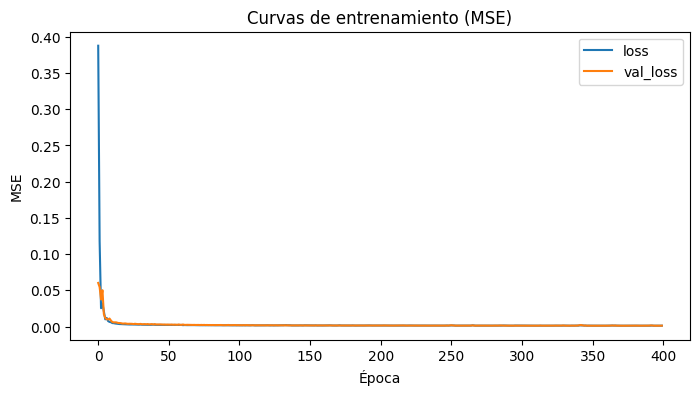

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=400,
    batch_size=16,
    verbose=1,
    callbacks=[es]
)

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Curvas de entrenamiento (MSE)")
plt.xlabel("Época"); plt.ylabel("MSE"); plt.legend(); plt.show()


# **Paso 6: métricas y gráfico 1-paso en el tramo TEST**

- Generamos predicciones 1-paso con el modelo ya entrenado.
- Construimos el índice de **fechas objetivo**: para una ventana `W`, cada `y` predicho corresponde a `series.index[W:]`.
- Filtramos **solo** las fechas cuyo objetivo cae en el rango de **TEST**.
- Reportamos MAE/RMSE en TEST y graficamos **Real vs Predicho** con las longitudes alineadas.


[TEST alineado] MAE=23.21  RMSE=28.64  (n=12)


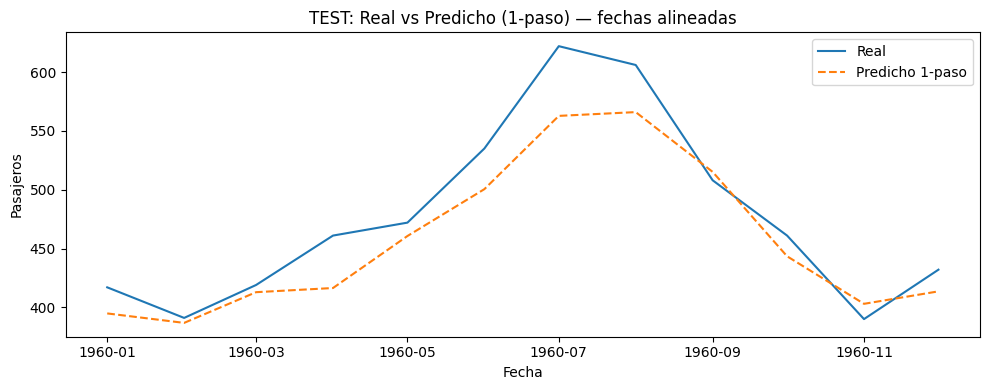

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# 1) Predicciones 1-paso sobre los sets ya preparados
y_hat_va_all = model.predict(X_va, verbose=0).flatten()
y_hat_te_all = model.predict(X_te, verbose=0).flatten()

# Invertimos a escala original
y_va_true_all = inverse_transform(y_va, scaler)
y_te_true_all = inverse_transform(y_te, scaler)
y_va_pred_all = inverse_transform(y_hat_va_all, scaler)
y_te_pred_all = inverse_transform(y_hat_te_all, scaler)

# 2) Construimos el índice de fechas de TODO el arreglo (train+valid+test)
s_full = pd.concat([s_train, s_valid, s_test])
full_t_len = len(train_t) + len(valid_t) + len(test_t)

# Fechas objetivo para X_te / y_te: empiezan en la posición W de s_full
dates_targets_all = s_full.index[W:]                   # len == len(y_te_true_all)

# 3) Máscara para quedarse SOLO con objetivos cuyo timestamp cae en TEST
mask_test = dates_targets_all >= s_test.index.min()
dates_test = dates_targets_all[mask_test]

y_te_true = y_te_true_all[mask_test]
y_te_pred = y_te_pred_all[mask_test]

# 4) Métricas SOLO en TEST (ya alineadas)
mae  = mean_absolute_error(y_te_true, y_te_pred)
rmse = math.sqrt(mean_squared_error(y_te_true, y_te_pred))
print(f"[TEST alineado] MAE={mae:.2f}  RMSE={rmse:.2f}  (n={len(y_te_true)})")

# 5) Gráfico Real vs Predicho en TEST (fechas alineadas)
plt.figure(figsize=(10,4))
plt.plot(dates_test, y_te_true, label="Real")
plt.plot(dates_test, y_te_pred, "--", label="Predicho 1-paso")
plt.title("TEST: Real vs Predicho (1-paso) — fechas alineadas")
plt.xlabel("Fecha"); plt.ylabel("Pasajeros"); plt.legend(); plt.tight_layout()
plt.show()


# **Visualización de predicciones multi-paso**

Después de entrenar la RNN mostramos un **panel de subplots**:
- Azul: historial de la ventana usada como entrada.
- Puntos azules: valores reales futuros.
- Cruces rojas: valores predichos por el modelo.
- Horizonte = 12 meses.

De esta manera se observa rápidamente cómo se comporta el modelo al extender sus predicciones.


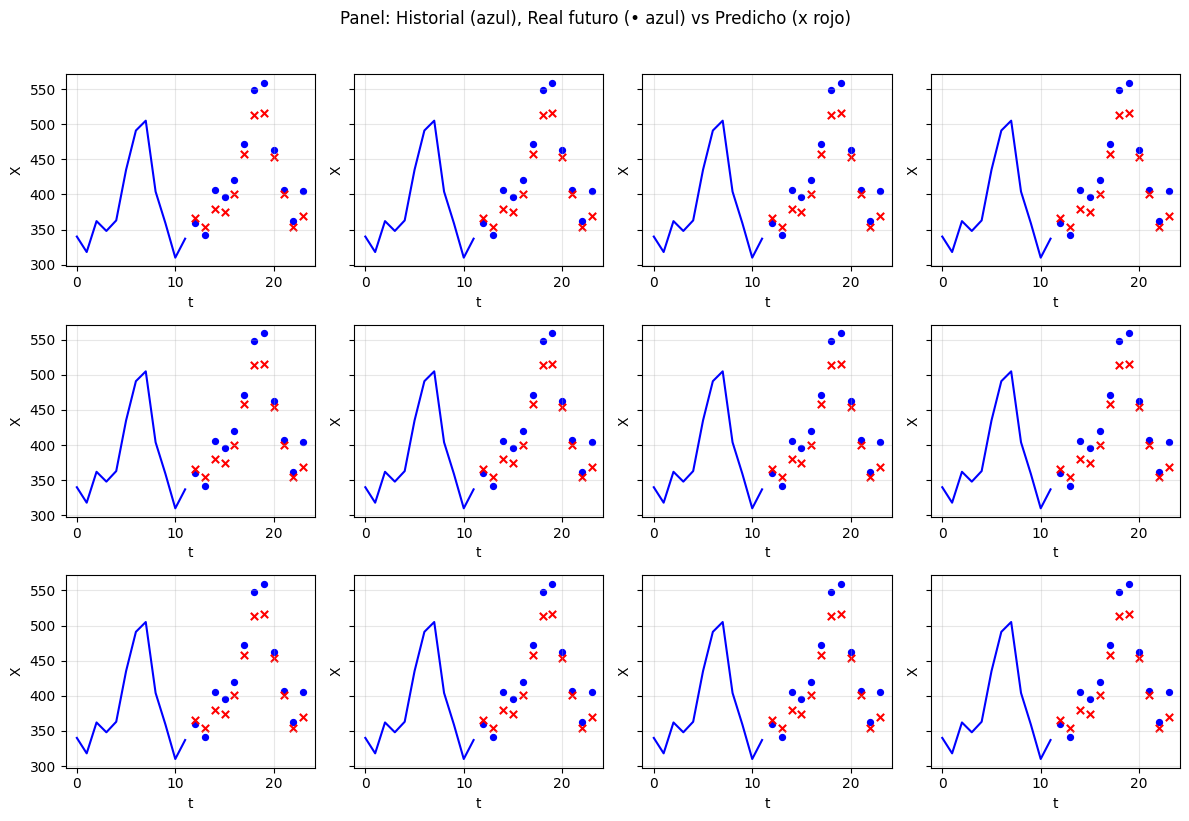

In [11]:
H = 12  # horizonte de predicción multi-paso

def forecast_autoreg(model, seed_seq, horizon, W):
    """Predicción autoregresiva H pasos usando una ventana semilla"""
    seq = seed_seq.astype(np.float32).copy()
    preds = []
    for _ in range(horizon):
        x = seq[-W:].reshape(1, W, 1)
        yhat = model.predict(x, verbose=0)[0,0]
        preds.append(yhat)
        seq = np.append(seq, yhat)
    return np.array(preds)

# Serie completa transformada
full_t = np.hstack([train_t, valid_t, test_t])

# Puntos de inicio (ventanas semillas en VALID+TEST)
start_valid = len(train_t)
max_start   = len(full_t) - (W + H)
starts = np.linspace(start_valid + W, max_start, 12, dtype=int)

def plot_panel(full_arr, starts, W=12, H=12):
    fig, axes = plt.subplots(3, 4, figsize=(12, 8), sharey=True)
    axes = axes.ravel()
    for ax, st in zip(axes, starts):
        past = full_arr[st-W:st]              # ventana historial
        true_future = full_arr[st:st+H]       # valores reales
        pred_future = forecast_autoreg(model, past, H, W)

        # Invertir escala
        past_inv = inverse_transform(past, scaler)
        true_inv = inverse_transform(true_future, scaler)
        pred_inv = inverse_transform(pred_future, scaler)

        # Eje x: historial y horizonte
        t_past = np.arange(len(past_inv))
        t_fut  = np.arange(len(past_inv), len(past_inv)+H)

        ax.plot(t_past, past_inv, color="blue")                     # historial
        ax.scatter(t_fut, true_inv, s=18, color="blue")             # reales
        ax.scatter(t_fut, pred_inv, marker="x", s=28, color="red")  # predicciones
        ax.set_xlabel("t"); ax.set_ylabel("X")
        ax.grid(True, alpha=0.3)

    fig.suptitle("Panel: Historial (azul), Real futuro (• azul) vs Predicho (x rojo)", y=1.02)
    plt.tight_layout()
    plt.show()

plot_panel(full_t, starts, W=W, H=H)


# **LSTM: entrenamiento, panel de predicciones y métricas**

Arquitectura:
- `LSTM(50, activation='tanh')`
- `Dense(1)` salida

Proceso:
1) Entrenar con `EarlyStopping`.  
2) Mostrar **panel** de 12 subplots (H=12, autoregresivo).  
3) Calcular **MAE/RMSE** en VALID y **TEST alineado**.  
4) Graficar **Real vs Predicho** (TEST).


Epoch 1/400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - loss: 0.2863 - val_loss: 0.2157
Epoch 2/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1158 - val_loss: 0.0583
Epoch 3/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0271 - val_loss: 0.0148
Epoch 4/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0212 - val_loss: 0.0253
Epoch 5/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0215 - val_loss: 0.0116
Epoch 6/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0109 - val_loss: 0.0159
Epoch 7/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0157 - val_loss: 0.0153
Epoch 8/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0113 - val_loss: 0.0121
Epoch 9/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0095 - val_loss: 0.0110
Epoch 10/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0100 - val_loss: 0.0109
Epoch 11/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0106 - val_loss: 0.0106
Epoch 12/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0095 - val_loss: 0.0109


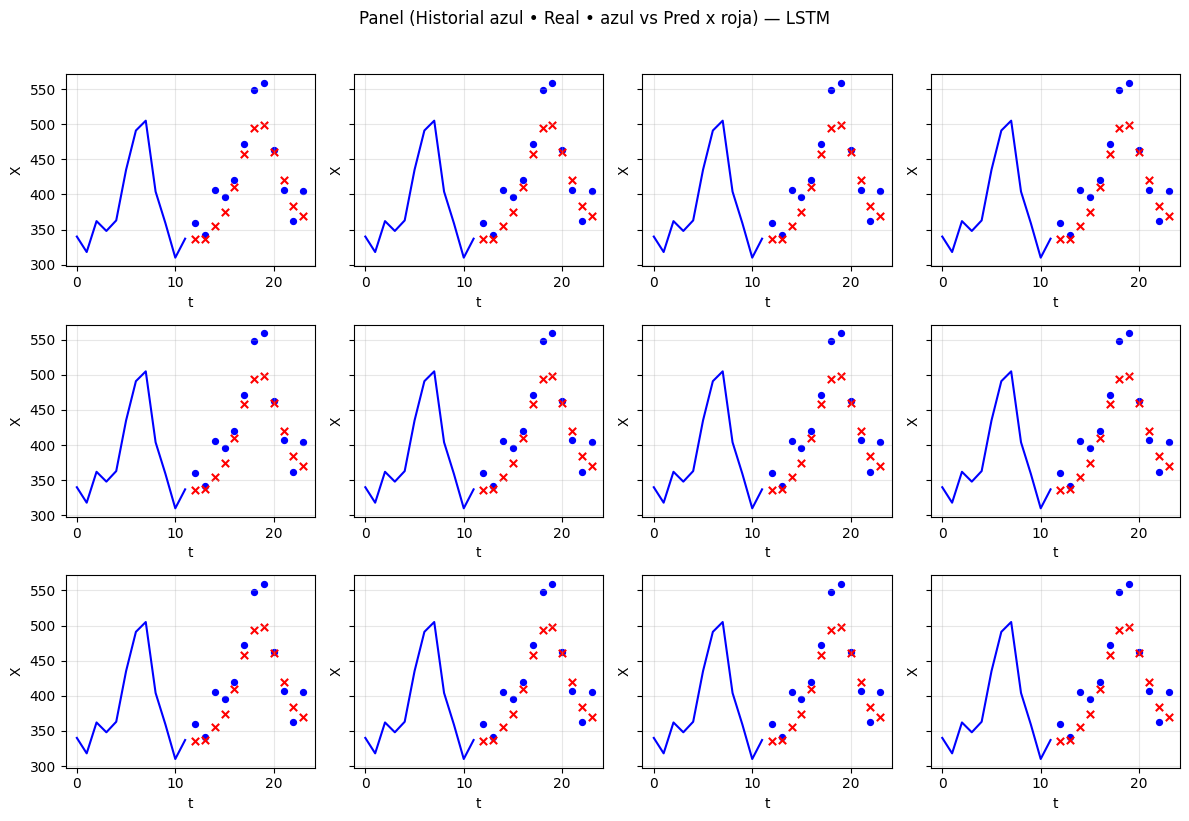

[LSTM VALID] MAE=15.33  RMSE=19.31
[LSTM TEST ] MAE=31.46  RMSE=37.33  (n=12)


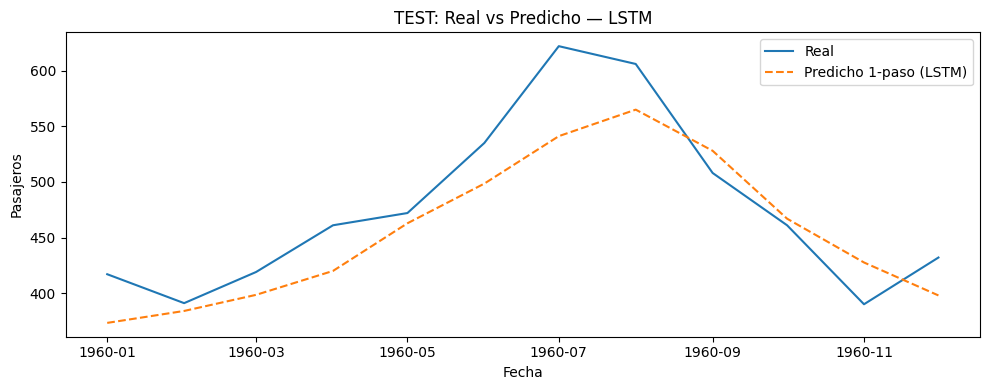

In [12]:
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math, pandas as pd

# --- construir y entrenar ---
lstm = Sequential([
    LSTM(50, activation="tanh", input_shape=(W,1)),
    Dense(1)
])
lstm.compile(optimizer="adam", loss="mse")

es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1)
hist_lstm = lstm.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=400, batch_size=16, verbose=1, callbacks=[es]
)

# --- panel inmediato (autoregresivo H=12) ---
H = 12
def forecast_autoreg(model, seed_seq, horizon, W):
    seq = seed_seq.astype(np.float32).copy()
    preds = []
    for _ in range(horizon):
        x = seq[-W:].reshape(1, W, 1)
        yhat = model.predict(x, verbose=0)[0,0]
        preds.append(yhat)
        seq = np.append(seq, yhat)
    return np.array(preds)

full_t = np.hstack([train_t, valid_t, test_t])
start_valid = len(train_t)
max_start   = len(full_t) - (W + H)
starts = np.linspace(start_valid + W, max_start, 12, dtype=int)

def plot_panel(model, full_arr, starts, W=12, H=12, title="LSTM"):
    fig, axes = plt.subplots(3, 4, figsize=(12, 8), sharey=True)
    axes = axes.ravel()
    for ax, st in zip(axes, starts):
        past = full_arr[st-W:st]
        true_future = full_arr[st:st+H]
        pred_future = forecast_autoreg(model, past, H, W)

        past_inv = inverse_transform(past, scaler)
        true_inv = inverse_transform(true_future, scaler)
        pred_inv = inverse_transform(pred_future, scaler)

        t_past = np.arange(len(past_inv))
        t_fut  = np.arange(len(past_inv), len(past_inv)+H)

        ax.plot(t_past, past_inv, color="blue")
        ax.scatter(t_fut, true_inv, s=18, color="blue")
        ax.scatter(t_fut, pred_inv, marker="x", s=28, color="red")
        ax.set_xlabel("t"); ax.set_ylabel("X"); ax.grid(True, alpha=0.3)

    fig.suptitle(f"Panel (Historial azul • Real • azul vs Pred x roja) — {title}", y=1.02)
    plt.tight_layout(); plt.show()

plot_panel(lstm, full_t, starts, W=W, H=H, title="LSTM")

# --- métricas VALID y TEST alineado + gráfico ---
y_hat_va_all = lstm.predict(X_va, verbose=0).flatten()
y_hat_te_all = lstm.predict(X_te, verbose=0).flatten()

y_va_true_all = inverse_transform(y_va, scaler)
y_te_true_all = inverse_transform(y_te, scaler)
y_va_pred_all = inverse_transform(y_hat_va_all, scaler)
y_te_pred_all = inverse_transform(y_hat_te_all, scaler)

# Fechas objetivo globales (corresponden a targets desde W en adelante)
s_full = pd.concat([s_train, s_valid, s_test])
dates_targets_all = s_full.index[W:]

# Filtrar solo TEST
mask_test = dates_targets_all >= s_test.index.min()
dates_test = dates_targets_all[mask_test]
y_te_true_lstm = y_te_true_all[mask_test]
y_te_pred_lstm = y_te_pred_all[mask_test]

# VALID (toda la serie de valid predicha 1-paso)
mae_va_lstm  = mean_absolute_error(y_va_true_all, y_va_pred_all)
rmse_va_lstm = math.sqrt(mean_squared_error(y_va_true_all, y_va_pred_all))
print(f"[LSTM VALID] MAE={mae_va_lstm:.2f}  RMSE={rmse_va_lstm:.2f}")

# TEST alineado
mae_te_lstm  = mean_absolute_error(y_te_true_lstm, y_te_pred_lstm)
rmse_te_lstm = math.sqrt(mean_squared_error(y_te_true_lstm, y_te_pred_lstm))
print(f"[LSTM TEST ] MAE={mae_te_lstm:.2f}  RMSE={rmse_te_lstm:.2f}  (n={len(y_te_true_lstm)})")

plt.figure(figsize=(10,4))
plt.plot(dates_test, y_te_true_lstm, label="Real")
plt.plot(dates_test, y_te_pred_lstm, "--", label="Predicho 1-paso (LSTM)")
plt.title("TEST: Real vs Predicho — LSTM")
plt.xlabel("Fecha"); plt.ylabel("Pasajeros"); plt.legend(); plt.tight_layout(); plt.show()


# **GRU: entrenamiento, panel de predicciones y métricas**

Arquitectura:
- `GRU(50, activation='tanh')`
- `Dense(1)` salida

Mismo pipeline:
1) Entrenar con `EarlyStopping`.  
2) Panel de 12 subplots (H=12).  
3) **MAE/RMSE** en VALID y TEST alineado.  
4) Gráfico **Real vs Predicho** (TEST).


Epoch 1/400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4271 - val_loss: 0.3480
Epoch 2/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2283 - val_loss: 0.1657
Epoch 3/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0939 - val_loss: 0.0553
Epoch 4/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0283 - val_loss: 0.0207
Epoch 5/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0234 - val_loss: 0.0265
Epoch 6/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0298 - val_loss: 0.0202
Epoch 7/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0183 - val_loss: 0.0198
Epoch 8/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0173 - val_loss: 0.0228
Epoch 9/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0164 - val_loss: 0.0217
Epoch 10/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0159 - val_loss: 0.0185
Epoch 11/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0128 - val_loss: 0.0164
Epoch 12/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0136 - val_loss: 0.0155
E

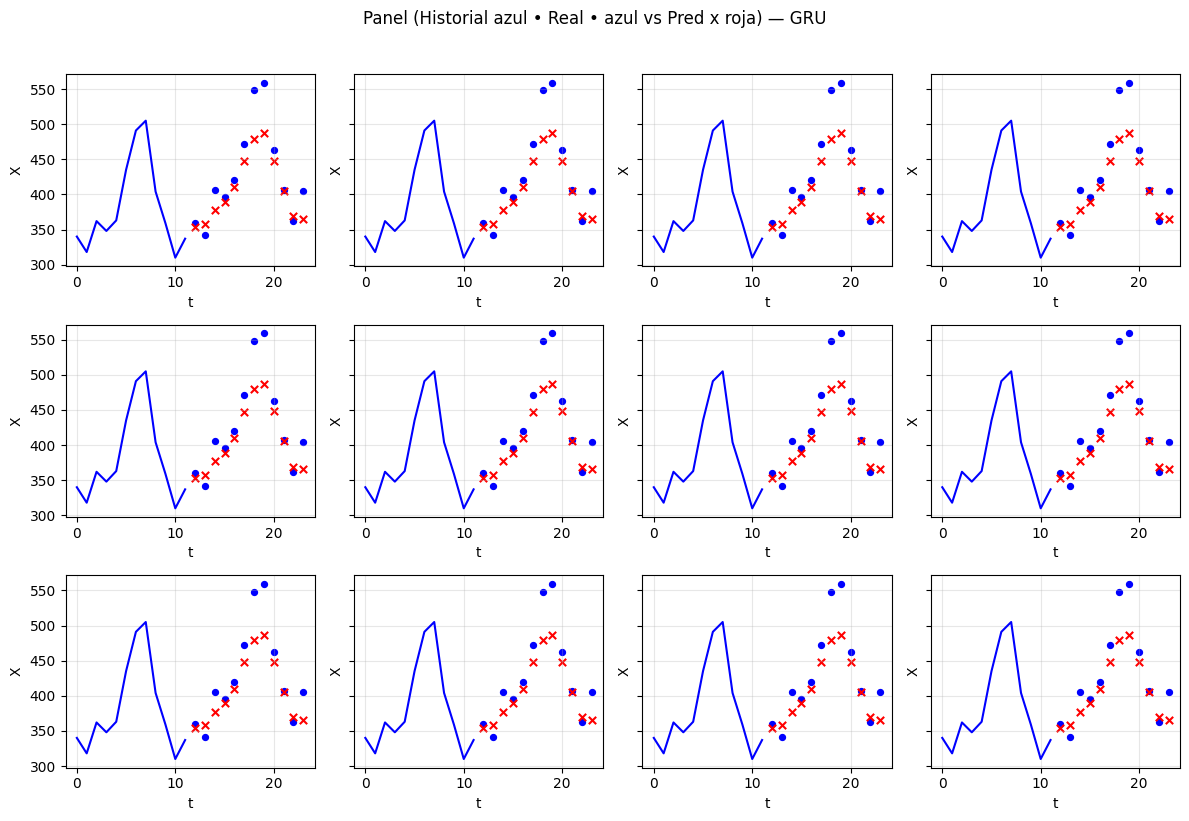

[GRU  VALID] MAE=13.16  RMSE=17.36
[GRU  TEST ] MAE=36.12  RMSE=45.65  (n=12)


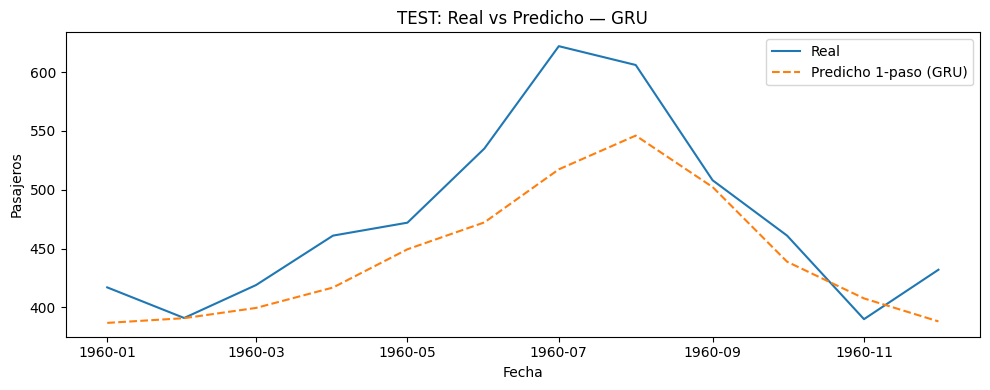

In [13]:
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math, pandas as pd

# --- construir y entrenar ---
gru = Sequential([
    GRU(50, activation="tanh", input_shape=(W,1)),
    Dense(1)
])
gru.compile(optimizer="adam", loss="mse")

es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1)
hist_gru = gru.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=400, batch_size=16, verbose=1, callbacks=[es]
)

# --- panel inmediato (autoregresivo H=12) ---
H = 12
def forecast_autoreg(model, seed_seq, horizon, W):
    seq = seed_seq.astype(np.float32).copy()
    preds = []
    for _ in range(horizon):
        x = seq[-W:].reshape(1, W, 1)
        yhat = model.predict(x, verbose=0)[0,0]
        preds.append(yhat)
        seq = np.append(seq, yhat)
    return np.array(preds)

full_t = np.hstack([train_t, valid_t, test_t])
start_valid = len(train_t)
max_start   = len(full_t) - (W + H)
starts = np.linspace(start_valid + W, max_start, 12, dtype=int)

plot_panel(gru, full_t, starts, W=W, H=H, title="GRU")

# --- métricas VALID y TEST alineado + gráfico ---
y_hat_va_all = gru.predict(X_va, verbose=0).flatten()
y_hat_te_all = gru.predict(X_te, verbose=0).flatten()

y_va_true_all = inverse_transform(y_va, scaler)
y_te_true_all = inverse_transform(y_te, scaler)
y_va_pred_all = inverse_transform(y_hat_va_all, scaler)
y_te_pred_all = inverse_transform(y_hat_te_all, scaler)

s_full = pd.concat([s_train, s_valid, s_test])
dates_targets_all = s_full.index[W:]

mask_test = dates_targets_all >= s_test.index.min()
dates_test = dates_targets_all[mask_test]
y_te_true_gru = y_te_true_all[mask_test]
y_te_pred_gru = y_te_pred_all[mask_test]

# VALID
mae_va_gru  = mean_absolute_error(y_va_true_all, y_va_pred_all)
rmse_va_gru = math.sqrt(mean_squared_error(y_va_true_all, y_va_pred_all))
print(f"[GRU  VALID] MAE={mae_va_gru:.2f}  RMSE={rmse_va_gru:.2f}")

# TEST
mae_te_gru  = mean_absolute_error(y_te_true_gru, y_te_pred_gru)
rmse_te_gru = math.sqrt(mean_squared_error(y_te_true_gru, y_te_pred_gru))
print(f"[GRU  TEST ] MAE={mae_te_gru:.2f}  RMSE={rmse_te_gru:.2f}  (n={len(y_te_true_gru)})")

plt.figure(figsize=(10,4))
plt.plot(dates_test, y_te_true_gru, label="Real")
plt.plot(dates_test, y_te_pred_gru, "--", label="Predicho 1-paso (GRU)")
plt.title("TEST: Real vs Predicho — GRU")
plt.xlabel("Fecha"); plt.ylabel("Pasajeros"); plt.legend(); plt.tight_layout(); plt.show()


# **Comparativa gráfica: RNN vs LSTM vs GRU**

- Mostramos en un mismo gráfico las predicciones de **TEST** de las tres redes.
- Comparamos contra los valores **reales**.
- Además, generamos un gráfico de barras con **MAE y RMSE** de cada modelo.
- Al final, destacamos el modelo con menor error como **el mejor**.


In [16]:
# --- Recalcular métricas para la RNN simple ---
y_hat_va_rnn = model.predict(X_va, verbose=0).flatten()
y_hat_te_rnn = model.predict(X_te, verbose=0).flatten()

y_va_true_rnn = inverse_transform(y_va, scaler)
y_te_true_rnn = inverse_transform(y_te, scaler)
y_va_pred_rnn = inverse_transform(y_hat_va_rnn, scaler)
y_te_pred_rnn = inverse_transform(y_hat_te_rnn, scaler)

# Fechas de targets globales
s_full = pd.concat([s_train, s_valid, s_test])
dates_targets_all = s_full.index[W:]

mask_test = dates_targets_all >= s_test.index.min()
dates_test = dates_targets_all[mask_test]

y_te_true_rnn = y_te_true_rnn[mask_test]
y_te_pred_rnn = y_te_pred_rnn[mask_test]

# Guardar métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

mae_te_rnn  = mean_absolute_error(y_te_true_rnn, y_te_pred_rnn)
rmse_te_rnn = math.sqrt(mean_squared_error(y_te_true_rnn, y_te_pred_rnn))
print(f"[RNN TEST] MAE={mae_te_rnn:.2f}  RMSE={rmse_te_rnn:.2f}")


[RNN TEST] MAE=23.21  RMSE=28.64


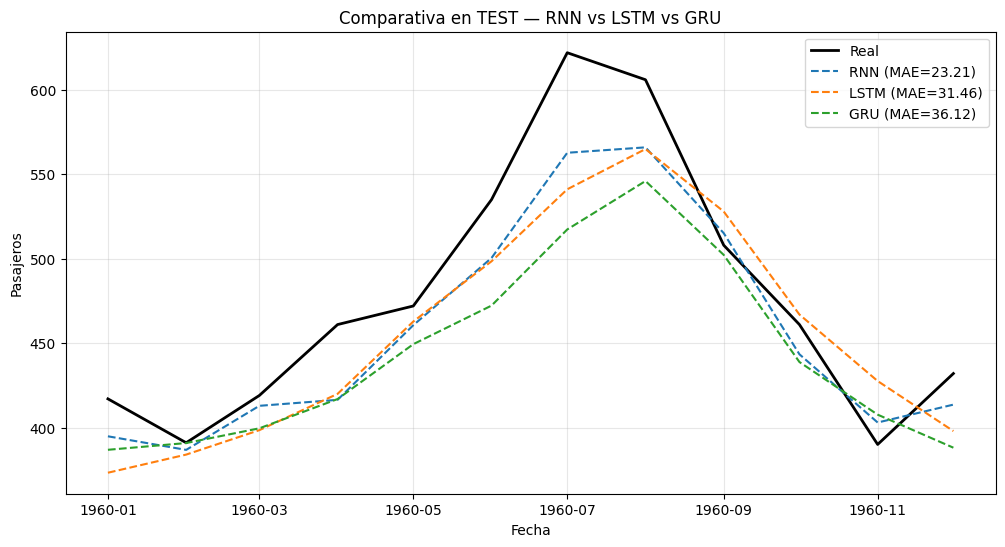

In [17]:
plt.figure(figsize=(12,6))
plt.plot(dates_test, y_te_true_rnn, label="Real", color="black", linewidth=2)
plt.plot(dates_test, y_te_pred_rnn, "--", label=f"RNN (MAE={mae_te_rnn:.2f})")
plt.plot(dates_test, y_te_pred_lstm, "--", label=f"LSTM (MAE={mae_te_lstm:.2f})")
plt.plot(dates_test, y_te_pred_gru, "--", label=f"GRU (MAE={mae_te_gru:.2f})")
plt.title("Comparativa en TEST — RNN vs LSTM vs GRU")
plt.xlabel("Fecha"); plt.ylabel("Pasajeros")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


# **Conclusiones comparativa RNN vs LSTM vs GRU**

- La **RNN simple** obtuvo el menor error (MAE≈23.21), ajustándose mejor a la serie real.  
- La **LSTM** mostró un desempeño intermedio con mayor error (MAE≈31.46).  
- La **GRU** fue la menos precisa en este conjunto de datos (MAE≈36.12).  

**Conclusión:** Para la serie Air Passengers, la red **RNN simple** fue la mejor alternativa, logrando las predicciones más cercanas a los valores reales en el conjunto de prueba.
